<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/Patient_CoxPH_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")



Mounted at /content/drive


In [2]:
!pip install -q lifelines scikit-survival

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 21.5 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index

from sklearn.preprocessing import StandardScaler

from sksurv.util import Surv
from sksurv.metrics import (
    cumulative_dynamic_auc,
    integrated_brier_score
)

BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/Clinical Patient/"
    "survival_model_ready_wout_protocol"
)

TRAIN_PATH = BASE_DIR / "train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "test_survival_model_ready.csv"

OUTPUT_DIR = BASE_DIR / "coxph_clinical_only_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train path:", TRAIN_PATH)
print("Validation path:", VALIDATION_PATH)
print("Test path:", TEST_PATH)
print("Output directory:", OUTPUT_DIR)

Train path: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/train_survival_model_ready.csv
Validation path: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/validation_survival_model_ready.csv
Test path: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/test_survival_model_ready.csv
Output directory: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/coxph_clinical_only_results


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (620, 43)
Validation shape: (177, 43)
Test shape: (89, 43)


In [5]:
def describe_survival_dataset(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Patients:", len(df))
    print("Observed events:", int(df["OS_EVENT"].sum()))
    print("Censored:", int((df["OS_EVENT"] == 0).sum()))
    print("Event rate:", round(df["OS_EVENT"].mean(), 3))
    print(
        "Survival-time range:",
        df["OS_DAYS"].min(),
        "to",
        df["OS_DAYS"].max(),
        "days"
    )
    print("Missing values:", int(df.isna().sum().sum()))


describe_survival_dataset(train_df, "Training set")
describe_survival_dataset(validation_df, "Validation set")
describe_survival_dataset(test_df, "Test set")


Training set
------------
Patients: 620
Observed events: 223
Censored: 397
Event rate: 0.36
Survival-time range: 1.0 to 4127.0 days
Missing values: 0

Validation set
--------------
Patients: 177
Observed events: 63
Censored: 114
Event rate: 0.356
Survival-time range: 1.0 to 4022.0 days
Missing values: 0

Test set
--------
Patients: 89
Observed events: 32
Censored: 57
Event rate: 0.36
Survival-time range: 8.0 to 3249.0 days
Missing values: 0


In [6]:
for col in train_df.columns:
    if "RISK" in col.upper() or "ELN" in col.upper():
        print(col)

RISK_GROUP_CLEAN_High
RISK_GROUP_CLEAN_Low
RISK_GROUP_CLEAN_Missing
RISK_GROUP_CLEAN_Standard


In [9]:
risk_cols = [
    "RISK_GROUP_CLEAN_High",
    "RISK_GROUP_CLEAN_Low",
    "RISK_GROUP_CLEAN_Standard",
    "RISK_GROUP_CLEAN_Missing"
]

print(train_df[risk_cols].sum())

RISK_GROUP_CLEAN_High         80.0
RISK_GROUP_CLEAN_Low         239.0
RISK_GROUP_CLEAN_Standard    278.0
RISK_GROUP_CLEAN_Missing      23.0
dtype: float64


In [103]:
for col in train_df.columns:
    if "CYTO" in col.upper():
        print(col)

PRIMARY_CYTOGENETIC_CODE_MLL
PRIMARY_CYTOGENETIC_CODE_Normal
PRIMARY_CYTOGENETIC_CODE_Other
PRIMARY_CYTOGENETIC_CODE_inv(16)
PRIMARY_CYTOGENETIC_CODE_t(8;21)
CYTOGENETIC_COMPLEXITY_GROUP_0
CYTOGENETIC_COMPLEXITY_GROUP_1
CYTOGENETIC_COMPLEXITY_GROUP_2
CYTOGENETIC_COMPLEXITY_GROUP_3
CYTOGENETIC_COMPLEXITY_GROUP_4_plus


In [104]:
continuous_features = [
    "AGE",
    "BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE",
    "PERIPHERAL_BLASTS_PERCENTAGE",
    "WBC_LOG1P"
]

categorical_features = [
    # Sex: Female is the reference category
    "SEX_Male",

    # Race: White is the reference category
    "RACE_American Indian or Alaska Native",
    "RACE_Asian",
    "RACE_Black or African American",
    "RACE_Native Hawaiian or other Pacific Islander",
    "RACE_Other",

    # Ethnicity: Not Hispanic or Latino is the reference category
    "ETHNICITY_Hispanic or Latino",

    # CNS disease: No is the reference category
    "CNS_DISEASE_Yes",

    # Chloroma: No is the reference category
    "CHLOROMA_Yes",

    # FAB NOS is the reference category
    "FAB_M0",
    "FAB_M1",
    "FAB_M2",
    "FAB_M4",
    "FAB_M5",
    "FAB_M6",
    "FAB_M7",

    # # Risk group: Low is the reference category
    #  "RISK_GROUP_CLEAN_Standard",
    #  "RISK_GROUP_CLEAN_High"


    #normal_ reference
    "PRIMARY_CYTOGENETIC_CODE_MLL",
    "PRIMARY_CYTOGENETIC_CODE_Other",
    "PRIMARY_CYTOGENETIC_CODE_inv(16)",
    "PRIMARY_CYTOGENETIC_CODE_t(8;21)",

    #0 reference
    "CYTOGENETIC_COMPLEXITY_GROUP_1",
    "CYTOGENETIC_COMPLEXITY_GROUP_2",
    "CYTOGENETIC_COMPLEXITY_GROUP_3",
    "CYTOGENETIC_COMPLEXITY_GROUP_4_plus",
]



clinical_features = continuous_features + categorical_features



duration_col = "OS_DAYS"
event_col = "OS_EVENT"
patient_id_col = "PATIENT_ID"

print("Number of clinical predictors:", len(clinical_features))
print("\nClinical predictors:")
for feature in clinical_features:
    print("-", feature)

Number of clinical predictors: 28

Clinical predictors:
- AGE
- BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
- PERIPHERAL_BLASTS_PERCENTAGE
- WBC_LOG1P
- SEX_Male
- RACE_American Indian or Alaska Native
- RACE_Asian
- RACE_Black or African American
- RACE_Native Hawaiian or other Pacific Islander
- RACE_Other
- ETHNICITY_Hispanic or Latino
- CNS_DISEASE_Yes
- CHLOROMA_Yes
- FAB_M0
- FAB_M1
- FAB_M2
- FAB_M4
- FAB_M5
- FAB_M6
- FAB_M7
- PRIMARY_CYTOGENETIC_CODE_MLL
- PRIMARY_CYTOGENETIC_CODE_Other
- PRIMARY_CYTOGENETIC_CODE_inv(16)
- PRIMARY_CYTOGENETIC_CODE_t(8;21)
- CYTOGENETIC_COMPLEXITY_GROUP_1
- CYTOGENETIC_COMPLEXITY_GROUP_2
- CYTOGENETIC_COMPLEXITY_GROUP_3
- CYTOGENETIC_COMPLEXITY_GROUP_4_plus


In [105]:
def check_required_columns(df, dataset_name, required_columns):
    missing_columns = [
        column for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing these columns:\n"
            + "\n".join(missing_columns)
        )

    print(f"{dataset_name}: all required columns are present.")


required_columns = (
    [patient_id_col]
    + clinical_features
    + [duration_col, event_col]
)

check_required_columns(train_df, "Training set", required_columns)
check_required_columns(validation_df, "Validation set", required_columns)
check_required_columns(test_df, "Test set", required_columns)

Training set: all required columns are present.
Validation set: all required columns are present.
Test set: all required columns are present.


In [106]:
def prepare_cox_dataframe(df):
    model_df = df[
        clinical_features + [duration_col, event_col]
    ].copy()

    for column in model_df.columns:
        model_df[column] = pd.to_numeric(
            model_df[column],
            errors="coerce"
        )

    if model_df.isna().any().any():
        problematic_columns = model_df.columns[
            model_df.isna().any()
        ].tolist()

        raise ValueError(
            "Missing or non-numeric values were found in: "
            f"{problematic_columns}"
        )

    if (model_df[duration_col] <= 0).any():
        raise ValueError(
            "All OS_DAYS values must be greater than zero."
        )

    invalid_events = ~model_df[event_col].isin([0, 1])

    if invalid_events.any():
        raise ValueError(
            "OS_EVENT must contain only 0 and 1."
        )

    model_df[event_col] = model_df[event_col].astype(int)

    return model_df


train_model_df = prepare_cox_dataframe(train_df)
validation_model_df = prepare_cox_dataframe(validation_df)
test_model_df = prepare_cox_dataframe(test_df)

print("Training modeling table:", train_model_df.shape)
print("Validation modeling table:", validation_model_df.shape)
print("Test modeling table:", test_model_df.shape)

Training modeling table: (620, 30)
Validation modeling table: (177, 30)
Test modeling table: (89, 30)


In [107]:
feature_screening = pd.DataFrame({
    "feature": clinical_features,
    "train_mean": [
        train_model_df[col].mean()
        for col in clinical_features
    ],
    "train_std": [
        train_model_df[col].std()
        for col in clinical_features
    ],
    "train_unique_values": [
        train_model_df[col].nunique()
        for col in clinical_features
    ],
    "train_nonzero_count": [
        (train_model_df[col] != 0).sum()
        for col in clinical_features
    ]
})

display(feature_screening)

,feature,train_mean,train_std,train_unique_values,train_nonzero_count
0,AGE,-1.074409e-16,1.000807,26,620
1,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,-7.449238e-17,1.000807,187,620
2,PERIPHERAL_BLASTS_PERCENTAGE,6.912034e-17,1.000807,128,620
3,WBC_LOG1P,-1.661753e-16,1.000807,452,620
4,SEX_Male,5.000000e-01,0.500404,2,310
5,RACE_American Indian or Alaska Native,4.838710e-03,0.069448,2,3
6,RACE_Asian,5.000000e-02,0.218121,2,31
7,RACE_Black or African American,1.096774e-01,0.312740,2,68
8,RACE_Native Hawaiian or other Pacific Islander,3.225806e-03,0.056750,2,2
9,RACE_Other,4.354839e-02,0.204253,2,27


In [108]:
constant_features = [
    feature
    for feature in clinical_features
    if train_model_df[feature].nunique() <= 1
]

if constant_features:
    print("Constant features removed:")
    for feature in constant_features:
        print("-", feature)
else:
    print("No constant features found.")

final_features = [
    feature
    for feature in clinical_features
    if feature not in constant_features
]

print("\nFinal number of predictors:", len(final_features))

No constant features found.

Final number of predictors: 28


In [175]:
PENALIZER = 0.10

coxph = CoxPHFitter(
    penalizer=PENALIZER,
    l1_ratio=1.00
)

coxph.fit(
    train_model_df[
        final_features + [duration_col, event_col]
    ],
    duration_col=duration_col,
    event_col=event_col,
    show_progress=True
)

coxph.print_summary()

Iteration 1: norm_delta = 6.26e-01, step_size = 0.9500, log_lik = -3225.14970, newton_decrement = 4.10e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 9.38e-02, step_size = 0.9500, log_lik = -2762.52208, newton_decrement = 1.48e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 4.54e-02, step_size = 0.9500, log_lik = -2434.78732, newton_decrement = 2.15e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 4.51e-02, step_size = 1.0000, log_lik = -2184.44897, newton_decrement = 2.12e-01, seconds_since_start = 0.1
Iteration 5: norm_delta = 4.58e-02, step_size = 1.0000, log_lik = -1992.68017, newton_decrement = 2.54e-01, seconds_since_start = 0.1
Iteration 6: norm_delta = 4.67e-02, step_size = 0.9800, log_lik = -1845.92955, newton_decrement = 3.07e-01, seconds_since_start = 0.1
Iteration 7: norm_delta = 4.67e-02, step_size = 0.9604, log_lik = -1733.76047, newton_decrement = 3.56e-01, seconds_since_start = 0.1
Iteration 8: norm_delta = 4.58e-02, step_size = 0.9412, log_li

<lifelines.CoxPHFitter: fitted with 620 total observations, 397 right-censored observations>
             duration col = 'OS_DAYS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 1.0
      baseline estimation = breslow
   number of observations = 620
number of events observed = 223
   partial log-likelihood = -1373.87
         time fit was run = 2026-07-24 09:56:54 UTC

---
                                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                       
AGE                                             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
PERIPHERAL_BLASTS_PERCENTAGE                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
WBC_LOG1P                                       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
SEX_Male                                       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
RACE_American Indian or Alaska Native          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
RACE_Asian                                      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
RACE_Black or African American                  0.07      1.08      0.23           -0.38            0.53                0.68                1.69
RACE_Native Hawaiian or other Pacific Islander -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
RACE_Other                                     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ETHNICITY_Hispanic or Latino                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
CNS_DISEASE_Yes                                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
CHLOROMA_Yes                                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M0                                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M1                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M2                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M4                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M5                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M6                                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
FAB_M7                                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
PRIMARY_CYTOGENETIC_CODE_MLL                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
PRIMARY_CYTOGENETIC_CODE_Other                  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
PRIMARY_CYTOGENETIC_CODE_inv(16)               -0.00      1.00      0.00           -0.00    

In [176]:
cox_summary = coxph.summary.reset_index()

cox_summary = cox_summary.rename(
    columns={"covariate": "feature"}
)

selected_summary_columns = [
    "feature",
    "coef",
    "exp(coef)",
    "se(coef)",
    "coef lower 95%",
    "coef upper 95%",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "z",
    "p"
]

cox_results = cox_summary[selected_summary_columns].copy()

cox_results = cox_results.rename(
    columns={
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hazard_ratio_lower_95",
        "exp(coef) upper 95%": "hazard_ratio_upper_95",
        "p": "p_value"
    }
)

cox_results["significant_p_lt_0.05"] = (
    cox_results["p_value"] < 0.05
)

cox_results = cox_results.sort_values(
    "p_value",
    ascending=True
)

display(cox_results)

cox_results.to_csv(
    OUTPUT_DIR / "coxph_clinical_only_coefficients.csv",
    index=False
)

,feature,coef,hazard_ratio,se(coef),coef lower 95%,coef upper 95%,hazard_ratio_lower_95,hazard_ratio_upper_95,z,p_value,significant_p_lt_0.05
7,RACE_Black or African American,7.263460e-02,1.075338,0.231394,-0.380889,0.526158,0.683254,1.692417,0.313901,0.753597,False
27,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,3.215900e-07,1.000000,0.000220,-0.000431,0.000431,0.999569,1.000432,0.001462,0.998834,False
23,PRIMARY_CYTOGENETIC_CODE_t(8;21),-1.976909e-07,1.000000,0.000144,-0.000283,0.000282,0.999717,1.000282,-0.001371,0.998906,False
13,FAB_M0,3.474667e-07,1.000000,0.000258,-0.000505,0.000506,0.999495,1.000506,0.001347,0.998925,False
1,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,6.347596e-08,1.000000,0.000048,-0.000094,0.000094,0.999906,1.000094,0.001327,0.998941,False
2,PERIPHERAL_BLASTS_PERCENTAGE,4.656158e-08,1.000000,0.000042,-0.000082,0.000082,0.999918,1.000082,0.001109,0.999115,False
22,PRIMARY_CYTOGENETIC_CODE_inv(16),-5.217875e-07,0.999999,0.000481,-0.000942,0.000941,0.999058,1.000942,-0.001086,0.999134,False
6,RACE_Asian,2.024608e-07,1.000000,0.000190,-0.000371,0.000372,0.999629,1.000372,0.001068,0.999148,False
10,ETHNICITY_Hispanic or Latino,1.045325e-07,1.000000,0.000104,-0.000204,0.000204,0.999796,1.000205,0.001002,0.999200,False
21,PRIMARY_CYTOGENETIC_CODE_Other,4.178038e-07,1.000000,0.000461,-0.000904,0.000904,0.999097,1.000905,0.000906,0.999277,False


In [177]:
def evaluate_c_index(model, df, dataset_name):
    predictors = df[final_features]

    partial_hazard = model.predict_partial_hazard(
        predictors
    ).values.ravel()

    c_index = concordance_index(
        event_times=df[duration_col],
        predicted_scores=-partial_hazard,
        event_observed=df[event_col]
    )

    print(f"{dataset_name} C-index: {c_index:.4f}")

    return c_index, partial_hazard


train_cindex, train_risk = evaluate_c_index(
    coxph,
    train_model_df,
    "Training"
)

validation_cindex, validation_risk = evaluate_c_index(
    coxph,
    validation_model_df,
    "Validation"
)

test_cindex, test_risk = evaluate_c_index(
    coxph,
    test_model_df,
    "Test"
)

Training C-index: 0.6525
Validation C-index: 0.6420
Test C-index: 0.6709


In [178]:
evaluation_results = pd.DataFrame({
    "dataset": [
        "Training",
        "Validation",
        "Test"
    ],
    "n_patients": [
        len(train_model_df),
        len(validation_model_df),
        len(test_model_df)
    ],
    "n_events": [
        int(train_model_df[event_col].sum()),
        int(validation_model_df[event_col].sum()),
        int(test_model_df[event_col].sum())
    ],
    "event_rate": [
        train_model_df[event_col].mean(),
        validation_model_df[event_col].mean(),
        test_model_df[event_col].mean()
    ],
    "c_index": [
        train_cindex,
        validation_cindex,
        test_cindex
    ]
})

display(evaluation_results)

evaluation_results.to_csv(
    OUTPUT_DIR / "coxph_clinical_only_evaluation.csv",
    index=False
)

,dataset,n_patients,n_events,event_rate,c_index
0,Training,620,223,0.359677,0.652547
1,Validation,177,63,0.355932,0.642027
2,Test,89,32,0.359551,0.670903


In [179]:
def create_prediction_table(
    original_df,
    model_df,
    risk_scores,
    dataset_name
):
    predictions = pd.DataFrame({
        patient_id_col: original_df[patient_id_col].values,
        duration_col: model_df[duration_col].values,
        event_col: model_df[event_col].values,
        "predicted_partial_hazard": risk_scores,
        "predicted_log_partial_hazard": np.log(risk_scores),
        "dataset": dataset_name
    })

    return predictions


train_predictions = create_prediction_table(
    train_df,
    train_model_df,
    train_risk,
    "train"
)

validation_predictions = create_prediction_table(
    validation_df,
    validation_model_df,
    validation_risk,
    "validation"
)

test_predictions = create_prediction_table(
    test_df,
    test_model_df,
    test_risk,
    "test"
)

all_predictions = pd.concat(
    [
        train_predictions,
        validation_predictions,
        test_predictions
    ],
    ignore_index=True
)

all_predictions.to_csv(
    OUTPUT_DIR / "coxph_clinical_only_patient_predictions.csv",
    index=False
)

display(test_predictions.head())

,PATIENT_ID,OS_DAYS,OS_EVENT,predicted_partial_hazard,predicted_log_partial_hazard,dataset
0,TARGET-21-PANVPB,421.0,1,0.992066,-0.007966,test
1,TARGET-20-PASHZX,623.0,1,0.992065,-0.007967,test
2,TARGET-20-PASKFN,2012.0,0,0.992065,-0.007967,test
3,TARGET-20-PATAST,1146.0,1,0.992065,-0.007967,test
4,TARGET-20-PASYRE,1433.0,0,0.992065,-0.007966,test


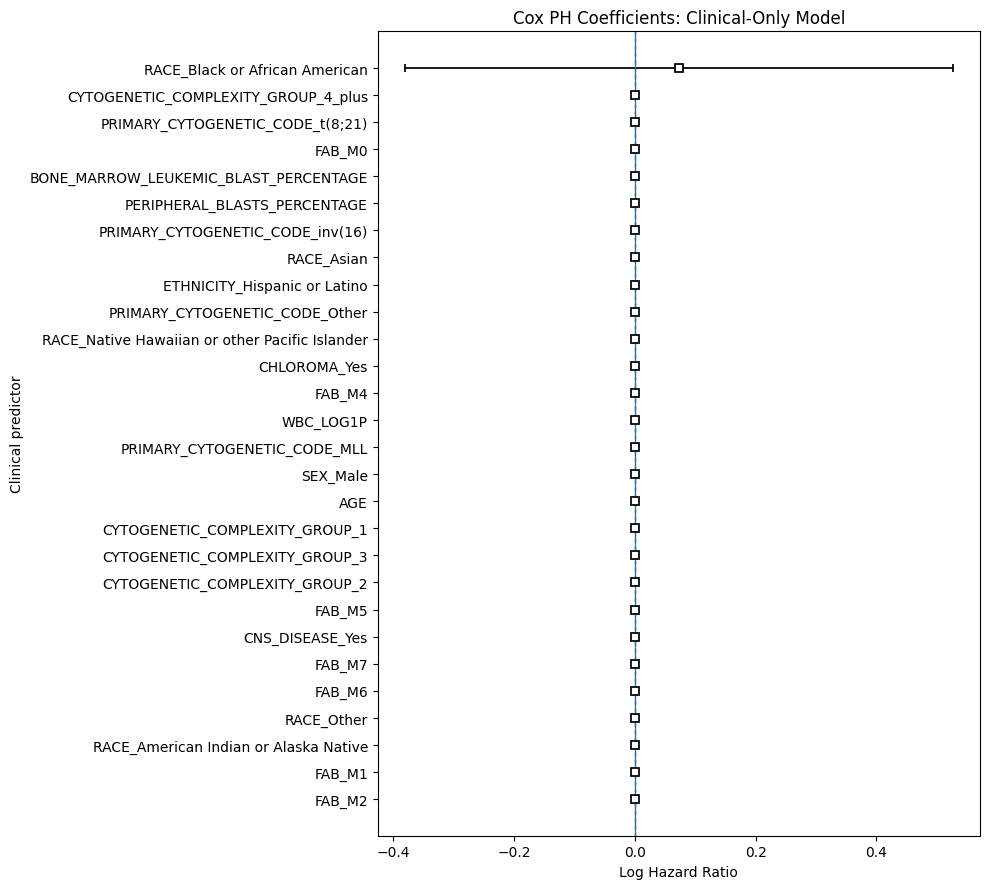

In [180]:
plt.figure(figsize=(10, 9))

coxph.plot(
    columns=cox_results["feature"].tolist()
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.title("Cox PH Coefficients: Clinical-Only Model")
plt.xlabel("Log Hazard Ratio")
plt.ylabel("Clinical predictor")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_clinical_only_coefficient_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

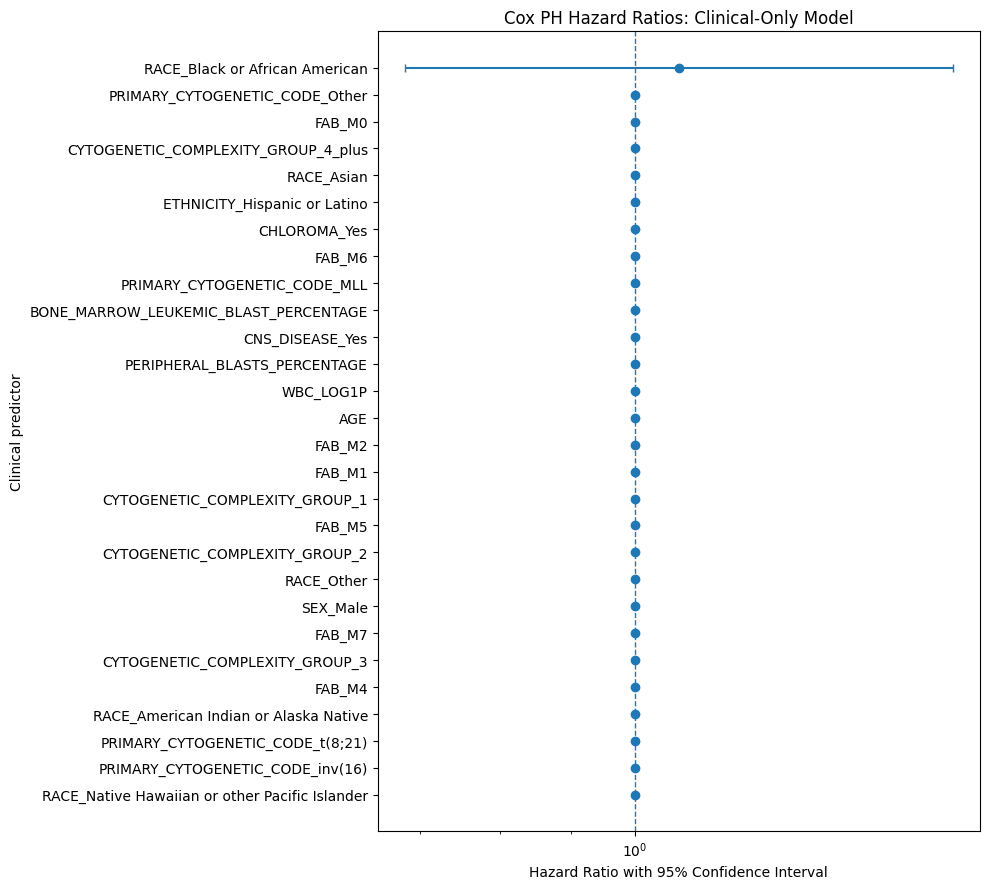

In [181]:
forest_df = cox_results.copy()

forest_df = forest_df.sort_values(
    "hazard_ratio",
    ascending=True
)

y_positions = np.arange(len(forest_df))

lower_error = (
    forest_df["hazard_ratio"]
    - forest_df["hazard_ratio_lower_95"]
)

upper_error = (
    forest_df["hazard_ratio_upper_95"]
    - forest_df["hazard_ratio"]
)

plt.figure(figsize=(10, 9))

plt.errorbar(
    forest_df["hazard_ratio"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=3
)

plt.axvline(
    x=1,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y_positions,
    forest_df["feature"]
)

plt.xscale("log")
plt.xlabel("Hazard Ratio with 95% Confidence Interval")
plt.ylabel("Clinical predictor")
plt.title("Cox PH Hazard Ratios: Clinical-Only Model")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_clinical_only_hazard_ratio_forest_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [182]:
ph_test = proportional_hazard_test(
    coxph,
    train_model_df[
        final_features + [duration_col, event_col]
    ],
    time_transform="rank"
)

ph_results = ph_test.summary.reset_index()

ph_results = ph_results.rename(
    columns={
        "index": "feature",
        "p": "ph_test_p_value"
    }
)

ph_results["possible_violation_p_lt_0.05"] = (
    ph_results["ph_test_p_value"] < 0.05
)

display(
    ph_results.sort_values(
        "ph_test_p_value"
    )
)

ph_results.to_csv(
    OUTPUT_DIR / "coxph_proportional_hazards_test.csv",
    index=False
)

,feature,test_statistic,ph_test_p_value,-log2(p),possible_violation_p_lt_0.05
23,RACE_Black or African American,4.920353e+00,0.026542,5.235574,True
1,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,2.589385e-06,0.998716,0.001853,False
2,CHLOROMA_Yes,2.023995e-06,0.998865,0.001639,False
22,RACE_Asian,1.868202e-06,0.998909,0.001574,False
19,PRIMARY_CYTOGENETIC_CODE_inv(16),1.302563e-06,0.999089,0.001314,False
13,FAB_M5,1.132591e-06,0.999151,0.001226,False
3,CNS_DISEASE_Yes,7.532312e-07,0.999308,0.000999,False
20,PRIMARY_CYTOGENETIC_CODE_t(8;21),6.921240e-07,0.999336,0.000958,False
14,FAB_M6,6.453524e-07,0.999359,0.000925,False
8,ETHNICITY_Hispanic or Latino,5.006114e-07,0.999435,0.000815,False



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See lin



1. Variable 'RACE_Black or African American' failed the non-proportional test: p-value is 0.0265.

   Advice: with so few unique values (only 2), you can include `strata=['RACE_Black or African
American', ...]` in the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess 

[[<Axes: xlabel='rank-transformed time\n(p=0.9997)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9997)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9987)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9987)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9996)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9996)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9999)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9999)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9997)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9997)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9996)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9996)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9989)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9989)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0265)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0332)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9998)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9998)'>],
 [<Axes: xlabel='rank-transformed tim

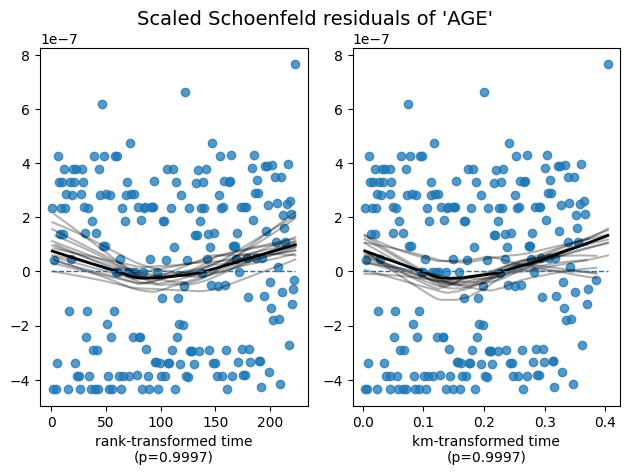

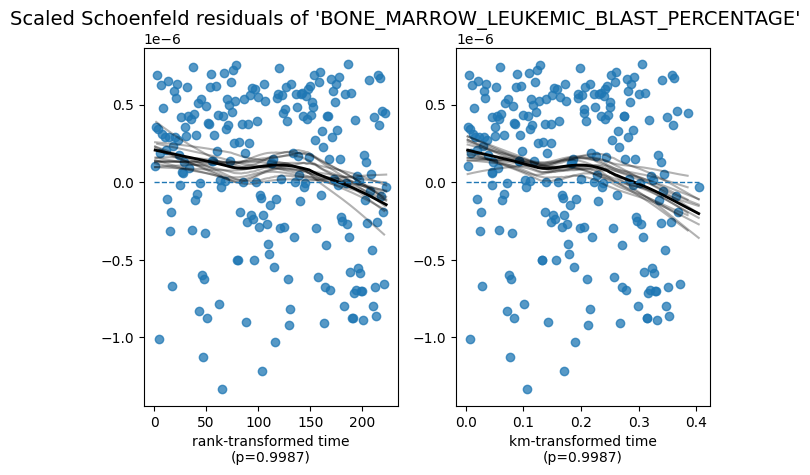

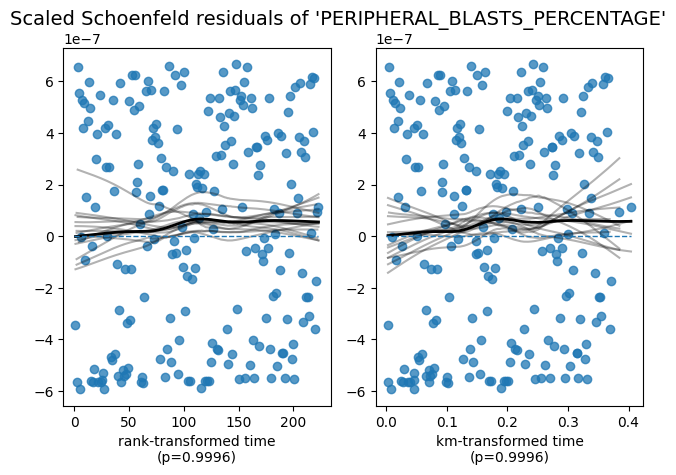

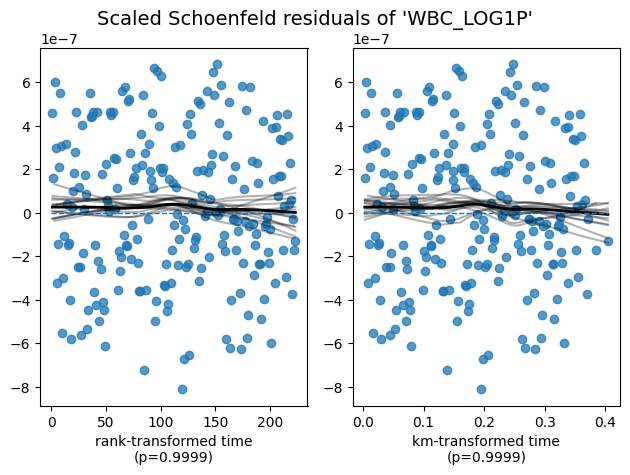

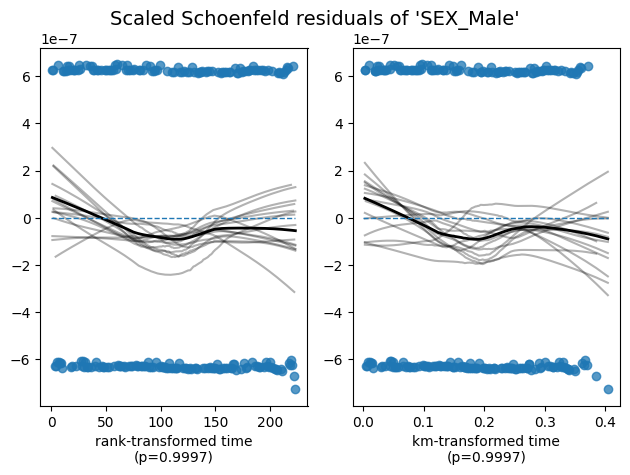

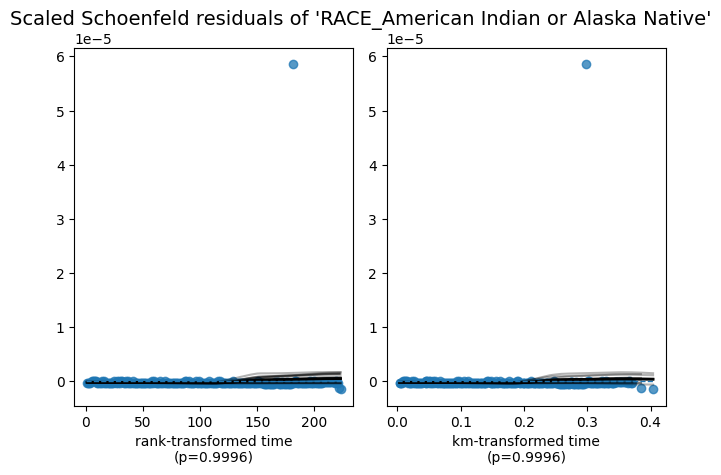

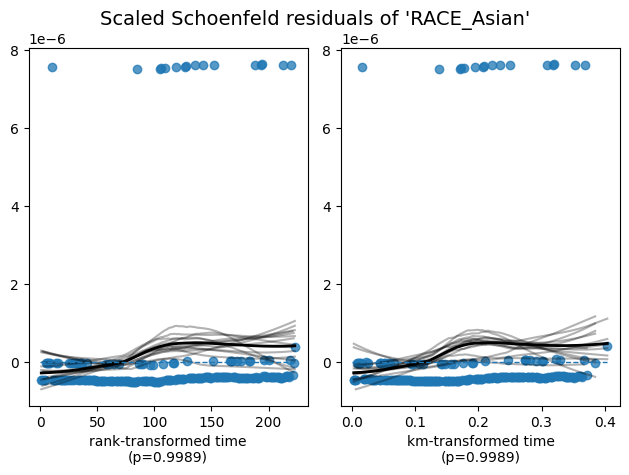

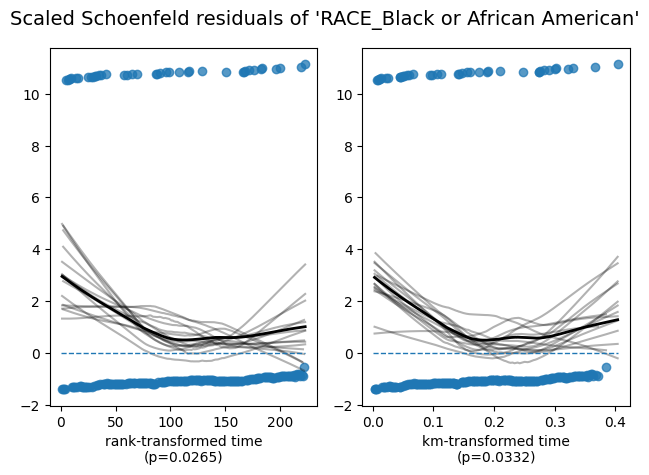

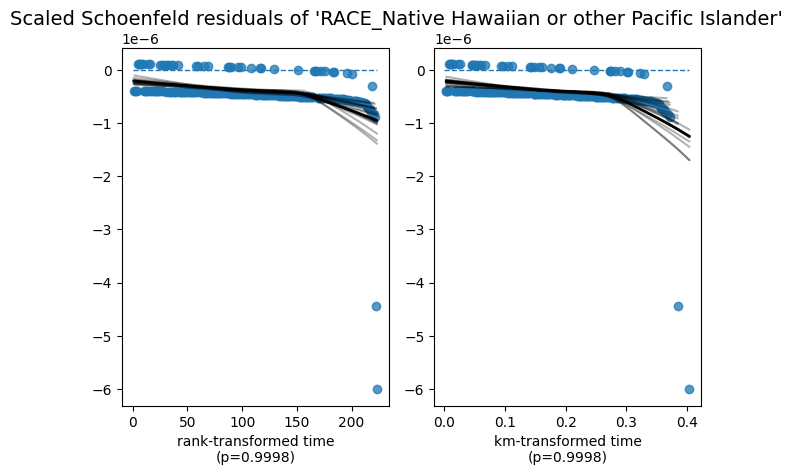

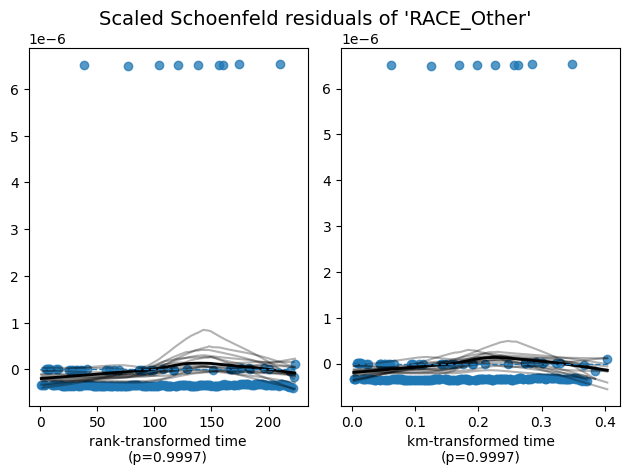

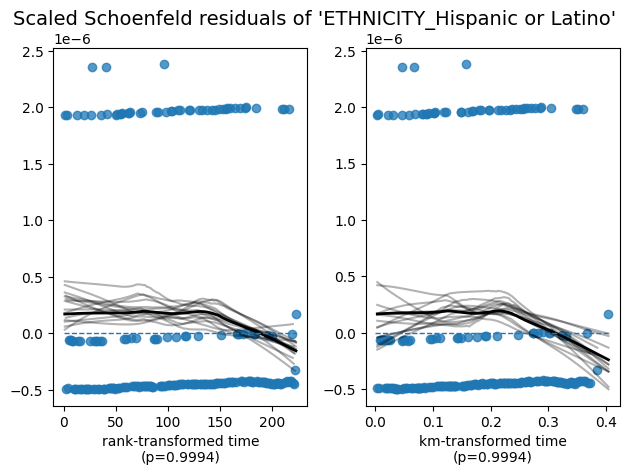

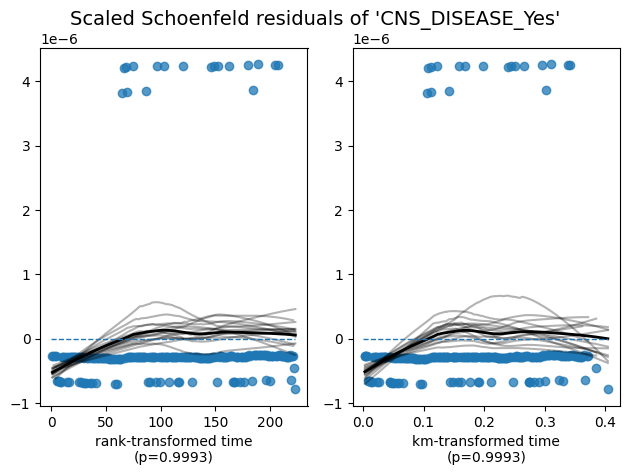

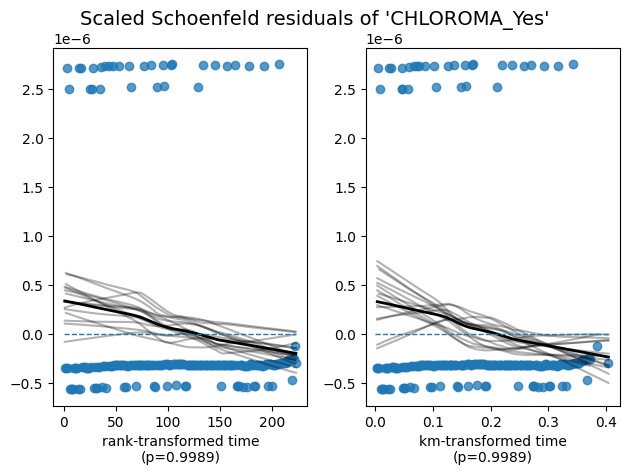

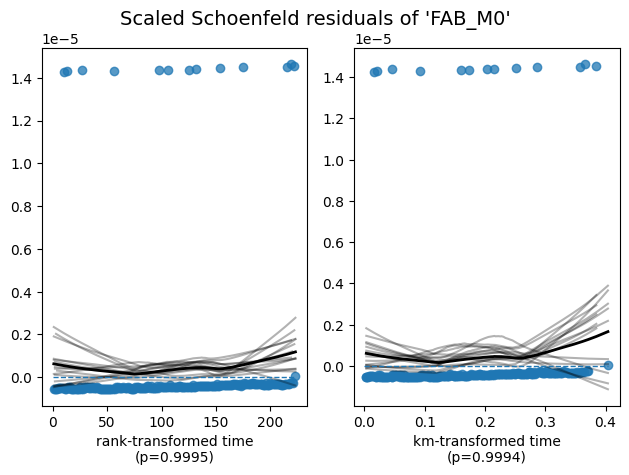

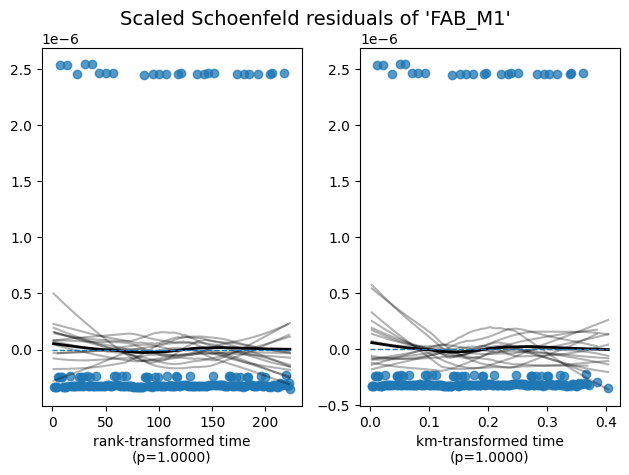

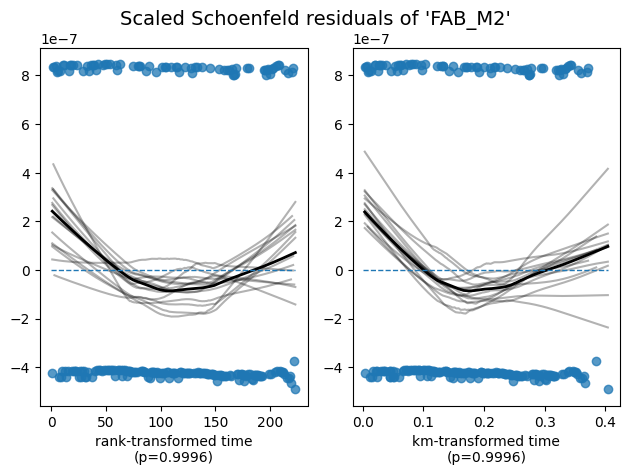

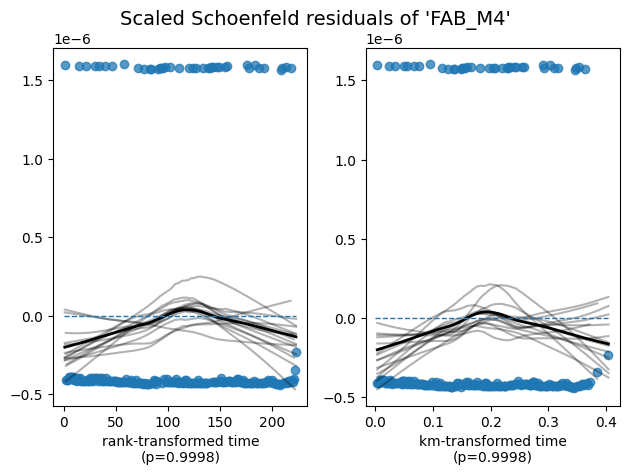

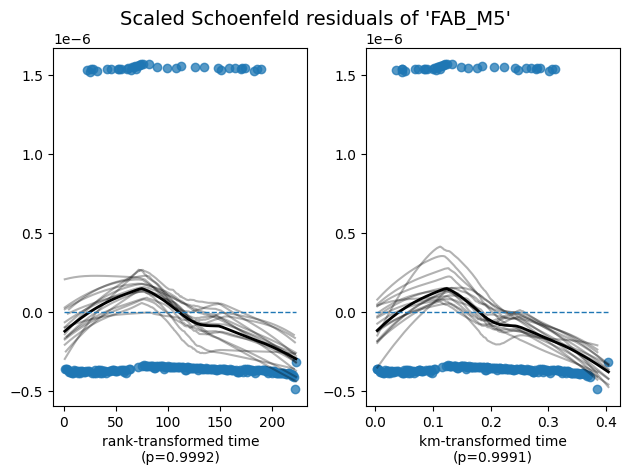

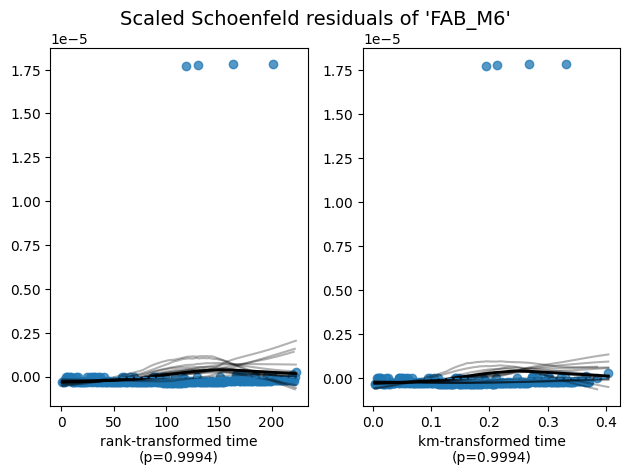

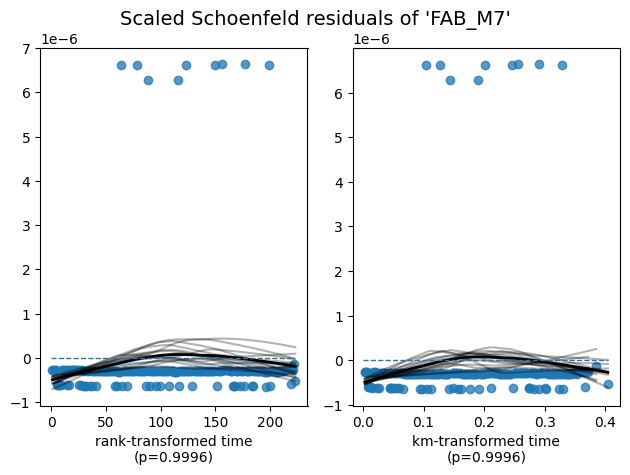

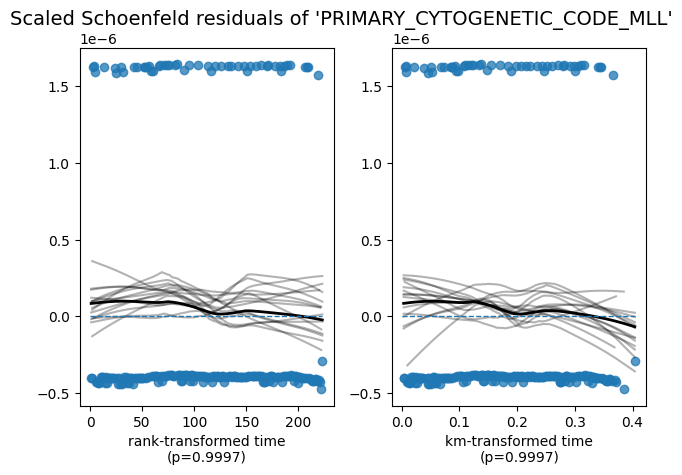

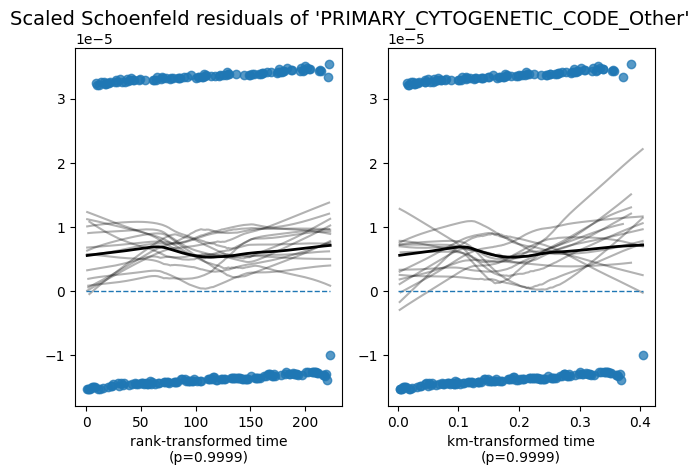

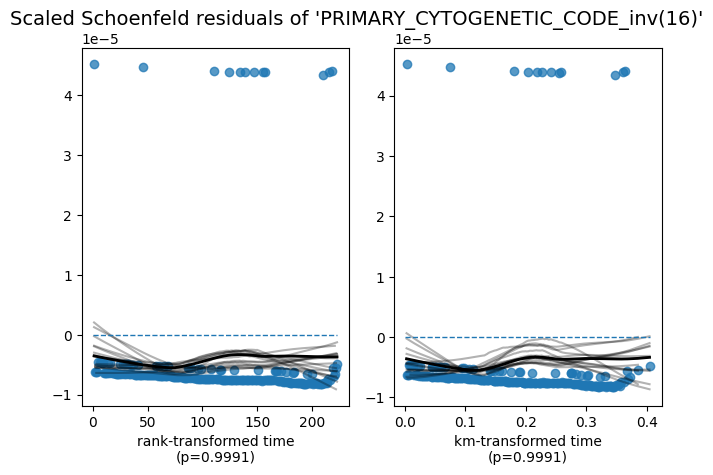

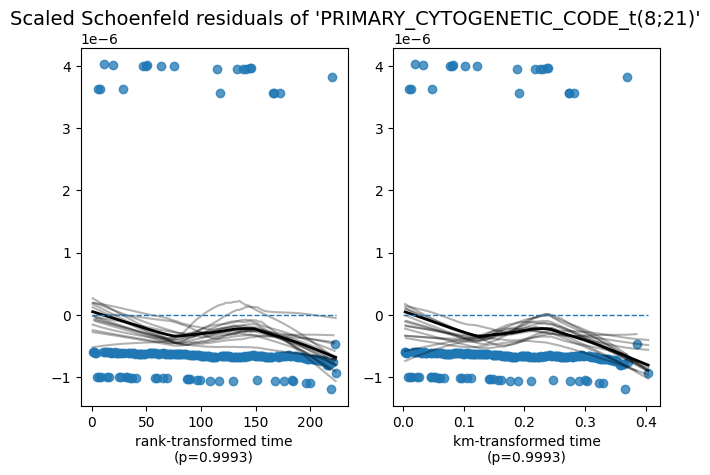

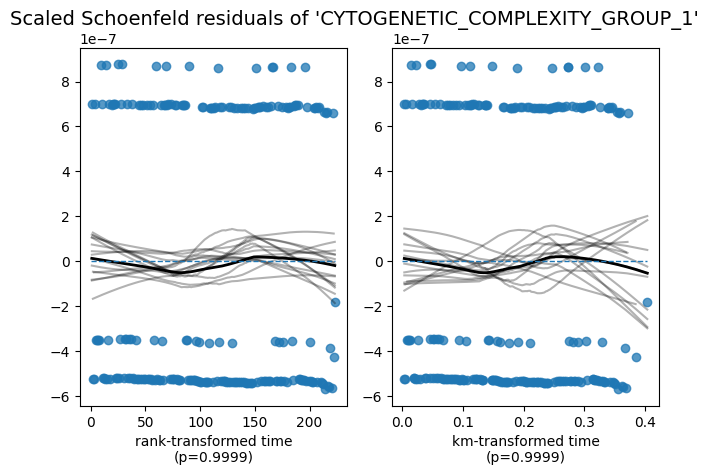

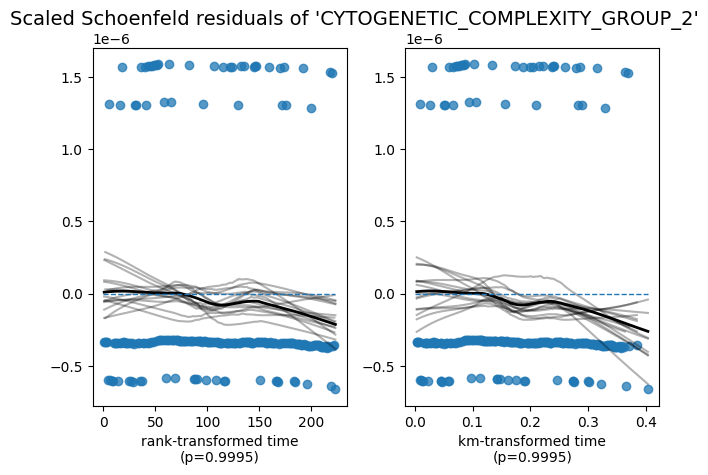

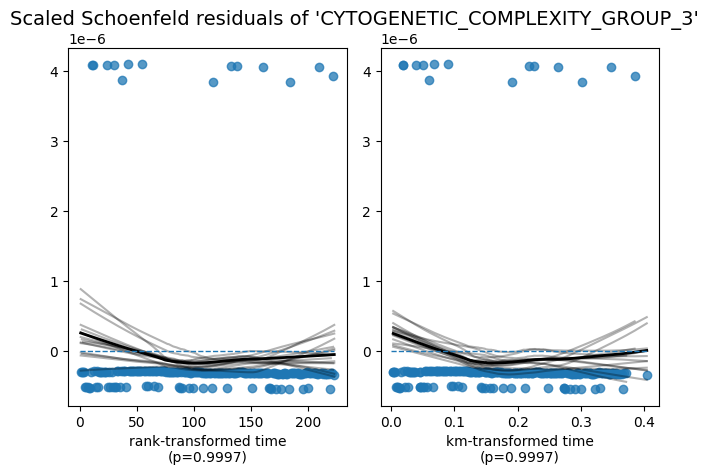

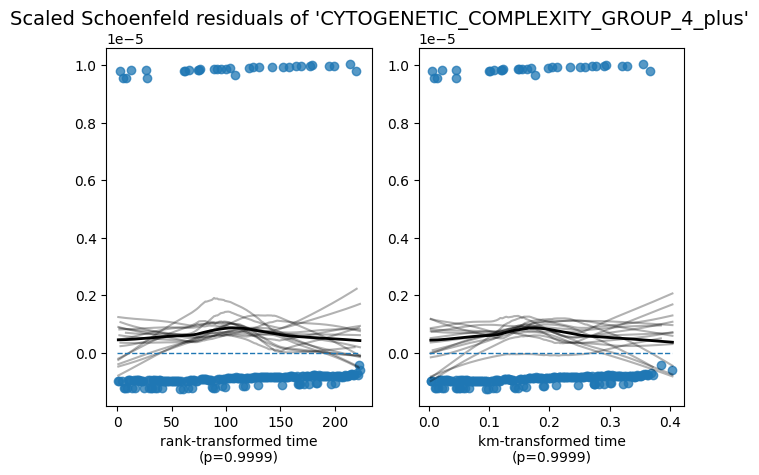

In [183]:
coxph.check_assumptions(
    train_model_df[
        final_features + [duration_col, event_col]
    ],
    p_value_threshold=0.05,
    show_plots=True
)

In [185]:
training_risk_cutoff = np.median(train_risk)

print(
    "Training-derived median risk cutoff:",
    training_risk_cutoff
)

Training-derived median risk cutoff: 0.9920653421514098


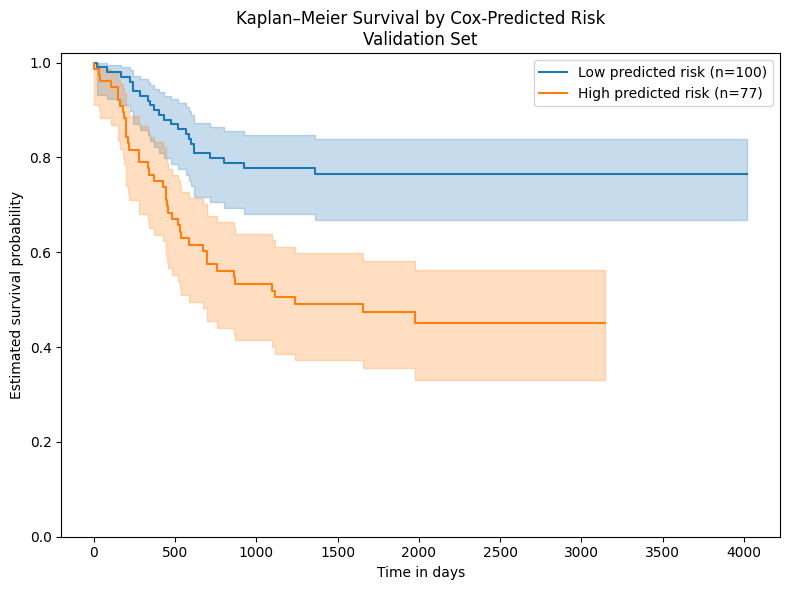

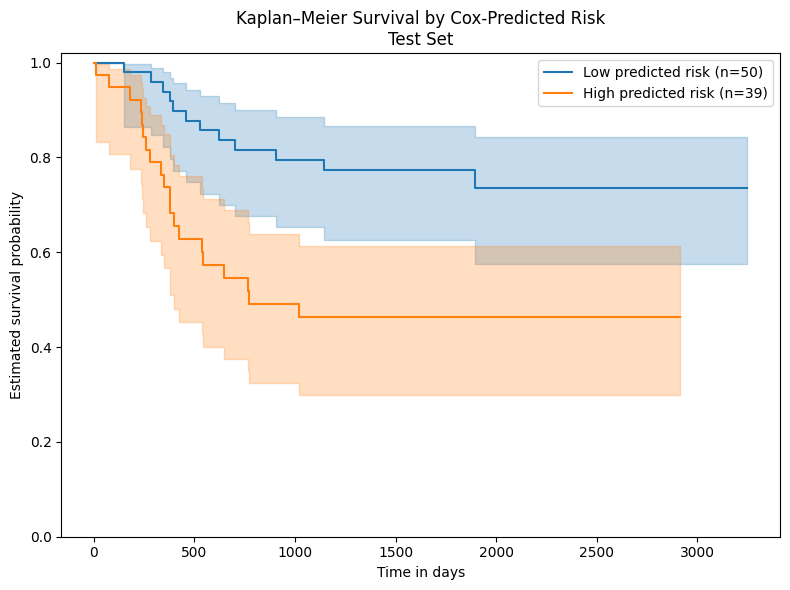

In [186]:
def plot_km_by_predicted_risk(
    model_df,
    risk_scores,
    cutoff,
    dataset_name,
    output_filename
):
    risk_group = np.where(
        risk_scores >= cutoff,
        "High predicted risk",
        "Low predicted risk"
    )

    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))

    for group in [
        "Low predicted risk",
        "High predicted risk"
    ]:
        mask = risk_group == group

        kmf.fit(
            durations=model_df.loc[mask, duration_col],
            event_observed=model_df.loc[mask, event_col],
            label=f"{group} (n={mask.sum()})"
        )

        kmf.plot_survival_function(
            ci_show=True
        )

    plt.title(
        f"Kaplan–Meier Survival by Cox-Predicted Risk\n"
        f"{dataset_name}"
    )
    plt.xlabel("Time in days")
    plt.ylabel("Estimated survival probability")
    plt.ylim(0, 1.02)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_km_by_predicted_risk(
    validation_model_df,
    validation_risk,
    training_risk_cutoff,
    "Validation Set",
    "coxph_validation_km_risk_groups.png"
)

plot_km_by_predicted_risk(
    test_model_df,
    test_risk,
    training_risk_cutoff,
    "Test Set",
    "coxph_test_km_risk_groups.png"
)

In [187]:
def make_survival_object(df):
    return Surv.from_arrays(
        event=df[event_col].astype(bool).values,
        time=df[duration_col].astype(float).values
    )


y_train = make_survival_object(train_model_df)
y_validation = make_survival_object(validation_model_df)
y_test = make_survival_object(test_model_df)

In [188]:
requested_times = np.array([
    365,
    730,
    1095,
    1825
], dtype=float)


def get_valid_evaluation_times(
    requested_times,
    train_df,
    evaluation_df
):
    lower_bound = max(
        train_df[duration_col].min(),
        evaluation_df[duration_col].min()
    )

    upper_bound = min(
        train_df[duration_col].max(),
        evaluation_df[duration_col].max()
    )

    valid_times = requested_times[
        (requested_times > lower_bound)
        & (requested_times < upper_bound)
    ]

    if len(valid_times) == 0:
        raise ValueError(
            "None of the requested evaluation times fall "
            "within the supported follow-up range."
        )

    return valid_times

In [189]:
validation_auc_times = get_valid_evaluation_times(
    requested_times,
    train_model_df,
    validation_model_df
)

validation_auc, validation_mean_auc = cumulative_dynamic_auc(
    y_train,
    y_validation,
    validation_risk,
    validation_auc_times
)

validation_auc_results = pd.DataFrame({
    "time_days": validation_auc_times,
    "time_years": validation_auc_times / 365.25,
    "auc": validation_auc
})

print("Validation mean time-dependent AUC:",
      round(validation_mean_auc, 4))

display(validation_auc_results)

Validation mean time-dependent AUC: 0.6642


,time_days,time_years,auc
0,365.0,0.999316,0.690220
1,730.0,1.998631,0.643734
2,1095.0,2.997947,0.647142
3,1825.0,4.996578,0.649061


In [190]:
test_auc_times = get_valid_evaluation_times(
    requested_times,
    train_model_df,
    test_model_df
)

test_auc, test_mean_auc = cumulative_dynamic_auc(
    y_train,
    y_test,
    test_risk,
    test_auc_times
)

test_auc_results = pd.DataFrame({
    "time_days": test_auc_times,
    "time_years": test_auc_times / 365.25,
    "auc": test_auc
})

print("Test mean time-dependent AUC:",
      round(test_mean_auc, 4))

display(test_auc_results)

Test mean time-dependent AUC: 0.7093


,time_days,time_years,auc
0,365.0,0.999316,0.730936
1,730.0,1.998631,0.684924
2,1095.0,2.997947,0.712197
3,1825.0,4.996578,0.734779


In [191]:
validation_auc_results.to_csv(
    OUTPUT_DIR / "coxph_validation_time_dependent_auc.csv",
    index=False
)

test_auc_results.to_csv(
    OUTPUT_DIR / "coxph_test_time_dependent_auc.csv",
    index=False
)

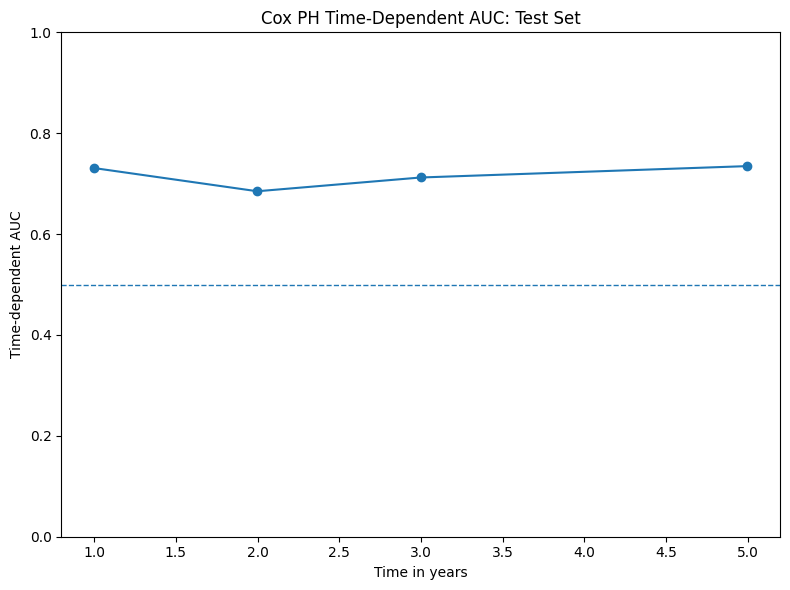

In [192]:
plt.figure(figsize=(8, 6))

plt.plot(
    test_auc_results["time_years"],
    test_auc_results["auc"],
    marker="o"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1
)

plt.ylim(0, 1)
plt.xlabel("Time in years")
plt.ylabel("Time-dependent AUC")
plt.title("Cox PH Time-Dependent AUC: Test Set")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_test_time_dependent_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [193]:
def create_brier_time_grid(
    train_df,
    evaluation_df,
    n_times=100
):
    lower_bound = max(
        train_df[duration_col].min(),
        evaluation_df[duration_col].min()
    )

    upper_bound = min(
        train_df[duration_col].max(),
        evaluation_df[duration_col].max()
    )

    lower_quantile = max(
        lower_bound + 1,
        evaluation_df[duration_col].quantile(0.10)
    )

    upper_quantile = min(
        upper_bound - 1,
        evaluation_df[duration_col].quantile(0.90)
    )

    if lower_quantile >= upper_quantile:
        raise ValueError(
            "Unable to construct a valid Brier-score time grid."
        )

    return np.linspace(
        lower_quantile,
        upper_quantile,
        n_times
    )

In [194]:
def predict_survival_probability_matrix(
    model,
    df,
    times
):
    survival_functions = model.predict_survival_function(
        df[final_features],
        times=times
    )

    # lifelines returns:
    # rows = times
    # columns = patients
    #
    # scikit-survival expects:
    # rows = patients
    # columns = times
    return survival_functions.T.values

In [195]:
validation_brier_times = create_brier_time_grid(
    train_model_df,
    validation_model_df
)

validation_survival_probabilities = (
    predict_survival_probability_matrix(
        coxph,
        validation_model_df,
        validation_brier_times
    )
)

validation_ibs = integrated_brier_score(
    y_train,
    y_validation,
    validation_survival_probabilities,
    validation_brier_times
)

print(
    "Validation Integrated Brier Score:",
    round(validation_ibs, 4)
)

Validation Integrated Brier Score: 0.2192


In [196]:
test_brier_times = create_brier_time_grid(
    train_model_df,
    test_model_df
)

test_survival_probabilities = (
    predict_survival_probability_matrix(
        coxph,
        test_model_df,
        test_brier_times
    )
)

test_ibs = integrated_brier_score(
    y_train,
    y_test,
    test_survival_probabilities,
    test_brier_times
)

print(
    "Test Integrated Brier Score:",
    round(test_ibs, 4)
)

Test Integrated Brier Score: 0.2077


In [197]:
additional_metrics = pd.DataFrame({
    "dataset": [
        "Validation",
        "Test"
    ],
    "c_index": [
        validation_cindex,
        test_cindex
    ],
    "mean_time_dependent_auc": [
        validation_mean_auc,
        test_mean_auc
    ],
    "integrated_brier_score": [
        validation_ibs,
        test_ibs
    ]
})

display(additional_metrics)

additional_metrics.to_csv(
    OUTPUT_DIR / "coxph_clinical_only_extended_metrics.csv",
    index=False
)

,dataset,c_index,mean_time_dependent_auc,integrated_brier_score
0,Validation,0.642027,0.664250,0.219229
1,Test,0.670903,0.709306,0.207680


In [198]:
CALIBRATION_TIME = 730.0
N_CALIBRATION_GROUPS = 5

def calibration_data_at_time(
    model,
    model_df,
    evaluation_time,
    n_groups=5
):
    predicted_survival = (
        model.predict_survival_function(
            model_df[final_features],
            times=[evaluation_time]
        )
        .iloc[0]
        .values
    )

    calibration_df = pd.DataFrame({
        "predicted_survival": predicted_survival,
        duration_col: model_df[duration_col].values,
        event_col: model_df[event_col].values
    })

    calibration_df["prediction_group"] = pd.qcut(
        calibration_df["predicted_survival"],
        q=n_groups,
        duplicates="drop"
    )

    results = []

    kmf = KaplanMeierFitter()

    for group, group_df in calibration_df.groupby(
        "prediction_group",
        observed=True
    ):
        kmf.fit(
            durations=group_df[duration_col],
            event_observed=group_df[event_col]
        )

        observed_survival = float(
            kmf.predict(evaluation_time)
        )

        results.append({
            "group": str(group),
            "n": len(group_df),
            "mean_predicted_survival":
                group_df["predicted_survival"].mean(),
            "observed_km_survival":
                observed_survival
        })

    return pd.DataFrame(results)

,group,n,mean_predicted_survival,observed_km_survival
0,"(0.70692108, 0.72430908]",18,0.715615,0.611111
1,"(0.72430908, 0.72430917]",18,0.724309,0.386364
2,"(0.72430917, 0.72430923]",17,0.724309,0.882353
3,"(0.72430923, 0.72430926]",18,0.724309,0.647059
4,"(0.72430926, 0.72430938]",18,0.724309,0.944444


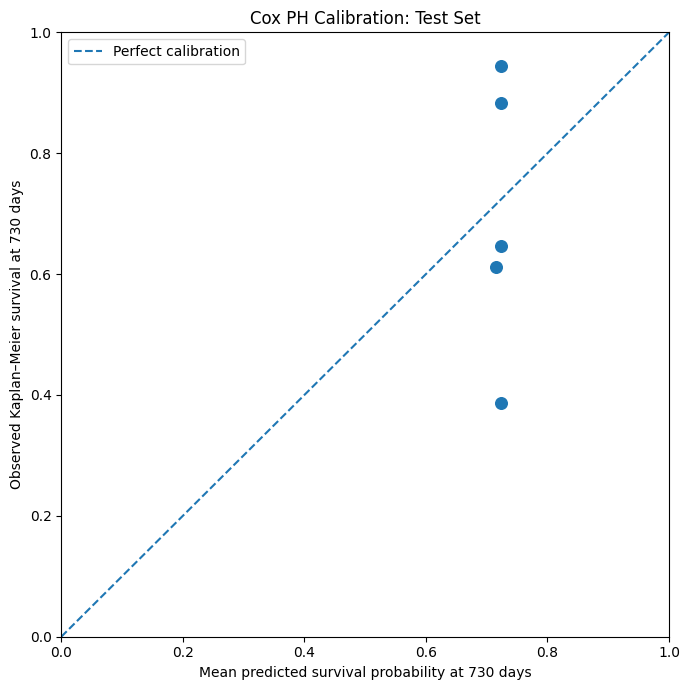

In [199]:
if CALIBRATION_TIME < test_model_df[duration_col].max():

    test_calibration = calibration_data_at_time(
        coxph,
        test_model_df,
        CALIBRATION_TIME,
        N_CALIBRATION_GROUPS
    )

    display(test_calibration)

    plt.figure(figsize=(7, 7))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.scatter(
        test_calibration["mean_predicted_survival"],
        test_calibration["observed_km_survival"],
        s=70
    )

    plt.xlabel(
        f"Mean predicted survival probability at "
        f"{int(CALIBRATION_TIME)} days"
    )
    plt.ylabel(
        f"Observed Kaplan–Meier survival at "
        f"{int(CALIBRATION_TIME)} days"
    )
    plt.title(
        "Cox PH Calibration: Test Set"
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "coxph_test_calibration_730_days.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    test_calibration.to_csv(
        OUTPUT_DIR / "coxph_test_calibration_730_days.csv",
        index=False
    )

else:
    print(
        "Two-year calibration cannot be calculated because "
        "the test follow-up is shorter than 730 days."
    )

In [200]:
import pickle

MODEL_PATH = OUTPUT_DIR / "coxph_clinical_only_model.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(coxph, file)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/coxph_clinical_only_results/coxph_clinical_only_model.pkl


In [201]:
final_summary = pd.DataFrame({
    "model": [
        "Cox proportional hazards",
        "Cox proportional hazards"
    ],
    "feature_set": [
        "Clinical only",
        "Clinical only"
    ],
    "dataset": [
        "Validation",
        "Test"
    ],
    "n_predictors": [
        len(final_features),
        len(final_features)
    ],
    "penalizer": [
        PENALIZER,
        PENALIZER
    ],
    "c_index": [
        validation_cindex,
        test_cindex
    ],
    "mean_time_dependent_auc": [
        validation_mean_auc,
        test_mean_auc
    ],
    "integrated_brier_score": [
        validation_ibs,
        test_ibs
    ],
    "partial_aic_training": [
        coxph.AIC_partial_,
        coxph.AIC_partial_
    ]
})

display(final_summary)

final_summary.to_csv(
    OUTPUT_DIR / "coxph_clinical_only_final_summary.csv",
    index=False
)

,model,feature_set,dataset,n_predictors,penalizer,c_index,mean_time_dependent_auc,integrated_brier_score,partial_aic_training
0,Cox proportional hazards,Clinical only,Validation,28,0.1,0.642027,0.664250,0.219229,2803.730618
1,Cox proportional hazards,Clinical only,Test,28,0.1,0.670903,0.709306,0.207680,2803.730618
